Implements raster and vector analysis using the TI-City model results and its spatial inputs.

### Authorship
@author: Alexandre Pereira Santos <br>
alexandre.santos(at)lmu.de<br>
- usespandas, geopandas, rasterio, rasterstats
- may include content from LLMs

### Features
1. Load ASCII files with ti-city NetLogo output
2. Assemble the ASCIIs as n-dimensional numpy vector, with n=number of runs
3. Load pre-calculated exposure metrics (TBD: segment exposure across RCP scenarios)
4. Calculate statistics for all runs (mean exposure, exposure per SEP, and vulnerability index [vuln = exposure degree * SEP class]
5. Plot stats as 
   1. Exposure vs. vulnerability map (t=2050) for each scenario
   2. Vulnerability index per scenario (line plot?), time on the x-axis

# Imports

In [3]:
import pandas as pd
import geopandas as gpd

import os
from pathlib import Path
import fnmatch
import shutil

import numpy as np
import random 
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import natsort

from shapely.geometry.polygon import Polygon
from shapely.geometry import MultiLineString, LineString
import json

import rasterio
from rasterio.mask import mask
from rasterio.plot import show, show_hist, plotting_extent
from rasterio.warp import reproject, calculate_default_transform, Resampling
from rasterio.features import dataset_features
import rasterstats
#from libpysal.weights import lat2W, Rook
#from esda.moran import Moran

# init

In [2]:
#input a vector and a raster file for each city
AOI_path = Path('../data/processed/')
MUM_file = 'MUM_LIM_reference_AOI_30m.shp' # APS: updated AOI 01.08.2024
MAN_file = 'MAN_LIM_reference_AOI_30m.shp' # APS: updated AOI 01.11.2024
JAK_file = 'JAK_LIM_reference_AOI_30m.shp' # APS: updated AOI 23.08.2024
#  the 'case_city' variable defines the city we are working on. APS: Need to update the code below to change it from MUM to the variable name

case_city = 'JAK' #MUM MAN JAK

if case_city == 'MUM':
    
    AOI_gdf = gpd.read_file(AOI_path / MUM_file) #.to_crs(epsg=4326)
    AOI_gdf_4326 = AOI_gdf.to_crs(epsg=4326) 

    ref_raster_path = Path('../data/processed/MUM_LIM_reference_AOI_30m.tif')
    ref_raster_150_path = Path('../data/processed/MUM_LIM_reference_AOI_150m.tif')
    

    raw_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\raw\\')
    interim_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\interim\\')
    processed_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\processed\\')
    external_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\external\\')
    model_inputs_30m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\model_inputs\\TIFF_30m\\')
    model_inputs_150m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\model_inputs\\TIFF_150m\\')
    model_outputs_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\model_outputs')
    model_inputs_SLEUTH_150m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\model_inputs\\TIFF_SLEUTH_150m')
    ascii150_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\model_inputs\\ASCII_150m')
    ascii150_SLEUTH_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MUM\\model_inputs\\ASCII_SLEUTH_150m')
    ti_city_ascii_path = Path('../model/MUM/data/in/')
    ti_city_out_path = Path('../model/MUM/data/out/')
    ref_raster_sleuth_path = model_inputs_SLEUTH_150m_path / (case_city + '_URB_SLEUTH_input_2022.tif' )

    gadm_var = 'NAME_3'
    calibration_years = [2015,2025]

if case_city == 'MAN':
    
    AOI_gdf = gpd.read_file(AOI_path / MAN_file) #.to_crs(epsg=4326)
    AOI_gdf_4326 = AOI_gdf.to_crs(epsg=4326) 

    ref_raster_path = Path('../data/processed/MAN_LIM_reference_AOI_30m.tif')
    ref_raster_150_path = Path('../data/processed/MAN_LIM_reference_AOI_150m.tif')

    raw_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\raw\\')
    interim_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\interim\\')
    processed_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\processed\\')
    external_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\external\\')
    model_inputs_30m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\model_inputs\\TIFF_30m\\')
    model_inputs_150m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\model_inputs\\TIFF_150m\\')
    model_inputs_SLEUTH_150m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\model_inputs\\TIFF_SLEUTH_150m')
    model_outputs_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\model_outputs')
    ascii150_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\model_inputs\\ASCII_150m')
    ascii150_SLEUTH_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\MAN\\model_inputs\\ASCII_SLEUTH_150m')
    ti_city_ascii_path = Path('../model/MAN/data/in/')
    ti_city_out_path = Path('../model/MAN/data/out/')
    ref_raster_sleuth_path = model_inputs_SLEUTH_150m_path / (case_city + '_URB_SLEUTH_input_2022.tif' )

    gadm_var = 'NAME_2'
    calibration_years = [2015,2025]

if case_city == 'JAK':
    
    AOI_gdf = gpd.read_file(AOI_path / JAK_file) #.to_crs(epsg=4326)
    AOI_gdf_4326 = AOI_gdf.to_crs(epsg=4326) 

    ref_raster_path = Path('../data/processed/JAK_LIM_reference_AOI_30m.tif')
    ref_raster_150_path = Path('../data/processed/JAK_LIM_reference_AOI_150m.tif')

    raw_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\raw\\')
    interim_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\interim\\')
    processed_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\processed\\')
    external_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\external\\')
    model_inputs_30m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\model_inputs\\TIFF_30m\\')
    model_inputs_150m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\model_inputs\\TIFF_150m\\')
    model_inputs_SLEUTH_150m_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\model_inputs\\TIFF_SLEUTH_150m')
    model_outputs_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\model_outputs')
    ascii150_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\model_inputs\\ASCII_150m')
    ascii150_SLEUTH_path = Path(r'D:\\Dropbox\\x\\PostDoc\\23 10 LMU\\13 exp_cases\\24 01 Urban SSP MAN MUM JAK\\05_GIS_temp\\JAK\\model_inputs\\ASCII_SLEUTH_150m')
    ti_city_ascii_path = Path('../model/JAK/data/in/')
    ti_city_out_path = Path('../model/JAK/data/out/')
    ref_raster_sleuth_path = model_inputs_SLEUTH_150m_path / (case_city + '_URB_SLEUTH_input_2022.tif' )

    gadm_var = 'NAME_2'
    calibration_years = [2015,2025]

external_data_path = Path(r'D:\\Dropbox\\x\\_data')
ascii150_arcgis_path = Path(r"D:\\Dropbox\\x\\PostDoc\ASCII_150m")

%run ./ti_city_00_raster_functions.ipynb

# read the reference raster
with rasterio.open(ref_raster_path,'r') as src:
    ref_raster = src
    ref_meta = src.meta
    ref_height, ref_width, ref_area = get_transform(ref_raster)



# suppress deprecation warnings
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

# 1. load ASCII results

## if necessary, import ASCIIs and export them to TIFFs

In [4]:
# first, let's inform the scenario folders
# APS: 15.05.2026 I updated the folder and file naming convention to allow for individual results per tick
# example: "D:\GIT\ti-city-model\model\JAK\data\out\R037\expansion_income_t0.asc"


std_path = 'R043/' #'R033_DT10 21 2230_N std first run/expansion_income_2050.asc' 
ssp1_path = 'R044/'#'R034_DT25 10 21 2330 N SSP1 first run/expansion_income_2050.asc' 
ssp2_path = 'R045/'#'R035_DT25 10 21 2350_N SSP2 first run/expansion_income_2050.asc'
ssp3_path = 'R046/'#'R036_DT25 10 21 2359 036_N SSP3 first run/expansion_income_2050.asc'

file_name_template = 'expansion_income_t'

# let's build dictionaries to support the loading functions
agent_class_dict = {'na':0,'low': 1, 'mid': 2, 'high': 3, 'deprived': 4, 'urban_2022': 5}
scenario_path_dict = {'std': std_path, 'ssp1':ssp1_path, 'ssp2': ssp2_path, 'ssp3': ssp3_path}
scenario_list = ['std' ,'ssp1', 'ssp2', 'ssp3']

# build a dict containing the ASCII files with the structure scenario > n-runs

results_dict_ascii = {}
for scenario in scenario_list:
    path = ti_city_out_path / scenario_path_dict[scenario]
    print(f'Processing content from: {scenario} at {path}')
    # example: "D:\GIT\ti-city-model\model\JAK\data\out\R037\expansion_income_t0.asc"
    # list and count the files in this folder
    ascii_files = [f for f in os.listdir(path) if f.endswith('.asc')]
    ascii_files = natsort.natsorted(ascii_files)  # Natural sorting
    #print(ascii_files)
    results_dict_ascii[scenario] = {}#{'list': ascii_files}
    
    for i in range(len(ascii_files)):
        file = ascii_files[i]
        #print('Loading file', i, 'name:', file)
        url = (path / file)
        #print(url)
        with rasterio.open(url, 'r') as src:
            array = src.read(1)
            array_meta = src.meta
            #results_dict_ascii[scenario] = {str(i) : array}
            results_dict_ascii[scenario][f'{i:03d}'] = array


# export the results raster to TIFFs
export_tiff = True #False
if export_tiff:
    for key, value in results_dict_ascii.items():
        #print(value)
        for i in range(len(ascii_files)):
            file_name = case_city + f'_TI-City_results_{key}_t{i:03d}.tif'
            
            dir_path = model_outputs_path / scenario_path_dict[key]
            dir_path.mkdir(parents=True, exist_ok=True)
            url = dir_path / file_name

            #print(f'Exporting: {file_name}')
            print(url)
            raster = value[f'{i:03d}']
            export_raster(raster = raster,
                        url = url,
                        data_type=rasterio.int16,
                        ref_raster_path=ref_raster_150_path
                        )
results_dict = results_dict_ascii

Processing content from: std at ..\model\JAK\data\out\R043
Processing content from: ssp1 at ..\model\JAK\data\out\R044
Processing content from: ssp2 at ..\model\JAK\data\out\R045
Processing content from: ssp3 at ..\model\JAK\data\out\R046
D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP MAN MUM JAK\05_GIS_temp\JAK\model_outputs\R043\JAK_TI-City_results_std_t000.tif
D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP MAN MUM JAK\05_GIS_temp\JAK\model_outputs\R043\JAK_TI-City_results_std_t001.tif
D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP MAN MUM JAK\05_GIS_temp\JAK\model_outputs\R043\JAK_TI-City_results_std_t002.tif
D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP MAN MUM JAK\05_GIS_temp\JAK\model_outputs\R043\JAK_TI-City_results_std_t003.tif
D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP MAN MUM JAK\05_GIS_temp\JAK\model_outputs\R043\JAK_TI-City_results_std_t004.tif
D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP M

## Otherwise, import the TIFFs

In [ ]:
# import the tiffs, with the correct reference raster
results_dict = {}
for result in results_list:
    
    key = result
    file_name = case_city + '_TI-City_results_' + key + '_2050.tif'
    with rasterio.open(processed_path / file_name, 'r') as src:
        array = src.read(1)
        array_meta = src.meta
        results_dict[result] = array
        print(key, array.shape)

std (680, 772)
ssp1 (680, 772)
ssp2 (680, 772)
ssp3 (680, 772)


Unique values [0. 1. 2. 3. 4. 5.] 
Min value 0.0 , Type: float32


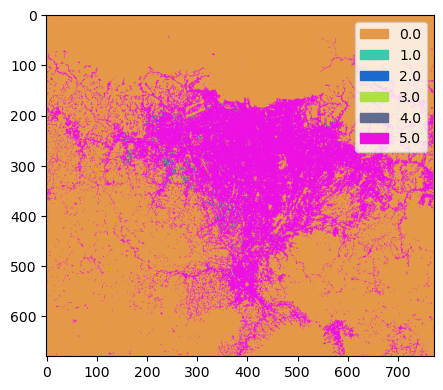

In [5]:
#fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(5,20))
%run ./ti_city_00_raster_functions.ipynb
from matplotlib.colors import LinearSegmentedColormap
plot_unique_value_raster(results_dict['ssp3']['001']) #, colors=['#ffffff','#6eca74','#98ABF7','#414bb2','#f0a1c5','#dbdbce'])

# 2. import the regions for analysis

(680, 772)
Min value: 0 , Max value: 3


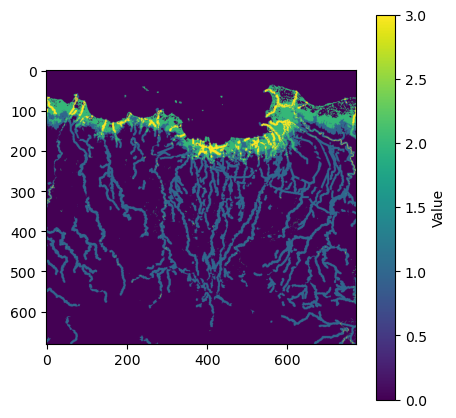

In [6]:
if case_city == 'MAN':
    file_name = case_city + '_HYD_25_year_flooding_surgeSSA1_reclass_150m.tif'
    exposure_areas_path = model_inputs_150m_path / file_name
elif case_city == 'JAK':
    file_name = case_city + '_HYD_flood_hazard_150m.tif'
    exposure_areas_path = interim_path / file_name
elif case_city == 'MUM':
    file_name = case_city + '_HYD_flood_hazard_150m.tif'
    exposure_areas_path = interim_path / file_name

with rasterio.open(exposure_areas_path,'r') as src:
    exposure_raster = src.read(1)
    exposure_raster_meta = src.meta
    # we have to adjust the area of the exposure raster to that of the results
print(exposure_raster.shape)
#plot_unique_value_raster(exposure_raster)
plot_continuous_raster(exposure_raster)
#plot_unique_value_raster(exposure_raster, title='Areas exposed to flooding (25 years return) and storm surge')

### MAN

In [30]:
file_name = case_city + '_HYD_25_year_flooding_surgeSSA1_reclass_150m.tif'
exposure_areas_path  = interim_path / file_name
ref_raster_sleuth_path
with rasterio.open(exposure_areas_path,'r') as src:
    src_array = src.read(1)
    # we have to adjust the area of the exposure raster to that of the results
    
    ref_array = results_dict_tiff['std']
    ref_bounds = results_dict_tiff['std'].bounds
    if src.crs == ref_raster.crs:
        bbox = [
            {
            'type': 'Polygon',
            'coordinates': [[
                [ref_bounds.left, ref_bounds.bottom],
                [ref_bounds.left, ref_bounds.top],
                [ref_bounds.right, ref_bounds.top],
                [ref_bounds.right, ref_bounds.bottom],
                [ref_bounds.left, ref_bounds.bottom]
                ]]
            }
        ]
        #print(bbox)
        try:
            exposure_raster, exposure_raster_transform = mask(src, bbox, crop=True)
            exposure_raster = exposure_raster[0]
            exposure_raster = exposure_raster.astype('int16')
        except ValueError:
            raise ValueError("The input raster does not intersect the reference raster.")
    else: print('CRS mismatch')
    #out_image, out_transform, out_meta = clip_raster_by_ref(exposure_areas_raster, ref_raster_sleuth_path)
    
print(exposure_raster.shape)
plot_unique_value_raster(exposure_raster, title='Areas exposed to flooding (25 years return) and storm surge')

RasterioIOError: D:\Dropbox\x\PostDoc\23 10 LMU\13 exp_cases\24 01 Urban SSP MAN MUM JAK\05_GIS_temp\JAK\interim\JAK_HYD_25_year_flooding_surgeSSA1_reclass_150m.tif: No such file or directory

In [ ]:
# import polygons for different city areas (e.g., municipalities in a metropolitan region)


# 3. Analysis

## 3.1 compile descriptive stats on the population for each SSP considering socioconomic profile and exposure

In [12]:
results_dict['std'][1]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [9]:
# prepare one table for SSP1, SSP2, SSP3, and the standard scenario
# the table should contain the following columns:
# - total urban area (i.e., the number of cells with a value of 1 in the raster, times the cell area)
# - total urban area exposed to flooding and storm surge (i.e., the number of cells with a value of 1 in the raster, in any exposure class, times the cell area)
# - the urban area for the deprived class (i.e., the number of cells with a value of 1 in the raster, times the cell area, for the deprived class)
# - the urban area for the deprived class exposed to flooding and storm surge (i.e., the number of cells with a value of 1 in the raster, in any exposure class, times the cell area, for the deprived class)
# the same for the other classes

# Define cell area (in square meters, for example)
cell_area = 0.150 * 0.150  # Assuming 150m x 150m cells,and returning area in square km

# Initialize a DataFrame to store the results
columns = [
    "Scenario",
    "Total Urban Area",
    "Urban Area Exposed to Flooding",
    "Urban Area (Deprived)",
    "Urban Area Exposed (Deprived)",
    "Urban Area (Low)",
    "Urban Area Exposed (Low)",
    "Urban Area (Mid)",
    "Urban Area Exposed (Mid)",
    "Urban Area (High)",
    "Urban Area Exposed (High)"
]

agent_class_dict = {'na':0,'deprived': 1, 'low': 2, 'mid': 3, 'high': 4, 'urban_first_year': 5}
agent_color_dict = {'low': '#6eca74', 'mid': '#98ABF7', 'high': '#414bb2', 'deprived': '#f0a1c5', 'urban_2022': '#dbdbce'}
start_year = 2025
#colors=['#ffffff','#6eca74','#98ABF7','#414bb2','#f0a1c5','#dbdbce']
descriptive_dict = {}
# Iterate through each scenario

for scenario, series in results_dict.items():
    # Total urban area (all classes except 'na')
    # iterate through the series in each scenario (e.g., 2015-2025) and calculate the stats for each year
    # Sort the keys naturally to ensure correct order
    sorted_keys = natsort.natsorted(series.keys())
    stats_dict = {}
    for i, key in enumerate(sorted_keys):
        raster = series[key]
        year = start_year + i
        print(f'index:{i}, year:{year}, key:{key}')

        if scenario not in descriptive_dict:
            descriptive_dict[scenario] = {}

        stats_dict = {}
        stats_dict['Total Urban Area'] = np.round(np.sum(raster > 0) * cell_area, 2)
        stats_dict['Urban Area Exposed to Flooding'] = np.round(np.sum((raster > 0) & (exposure_raster > 0)) * cell_area, 2)
        stats_dict['Total New Urban Area'] = np.round(stats_dict['Total Urban Area'] - (np.sum(raster == agent_class_dict['urban_first_year']) * cell_area), 2)
        stats_dict['New Urban Area Exposed to Flooding'] = np.round(stats_dict['Urban Area Exposed to Flooding'] - (np.sum((raster == agent_class_dict['urban_first_year']) & (exposure_raster > 0)) * cell_area), 2)

        # Calculate for each class
        for class_name, class_id in agent_class_dict.items():
            if class_name == 'na':
                continue  # Skip 'na' as it's not a class of interest
            stats_dict[f'Urban Area ({class_name})'] = np.round(np.sum(raster == class_id) * cell_area, 2)
            stats_dict[f'Urban Area Exposed ({class_name})'] = np.round(np.sum((raster == class_id) & (exposure_raster > 0)) * cell_area, 2)

        descriptive_dict[scenario][year] = stats_dict

# Display the results table
rows = []
for scenario, years in descriptive_dict.items():
    for year, stats in years.items():
        row = {"Scenario": scenario, "Year": year}
        row.update(stats)
        rows.append(row)

results_table = pd.DataFrame(rows)

results_table = results_table.sort_values(["Scenario", "Year"]).reset_index(drop=True)
results_table

# Export the results table to an Excel file
output_file = model_outputs_path / (case_city + '_urban_exposed_areas_analysis.xlsx')
results_table.to_excel(output_file, index_label="Scenario")
print(f"Results table exported to {output_file}")



index:0, year:2025, key:000
index:1, year:2026, key:001
index:2, year:2027, key:002
index:3, year:2028, key:003
index:4, year:2029, key:004
index:5, year:2030, key:005
index:6, year:2031, key:006
index:7, year:2032, key:007
index:8, year:2033, key:008
index:9, year:2034, key:009
index:10, year:2035, key:010
index:11, year:2036, key:011
index:12, year:2037, key:012
index:13, year:2038, key:013
index:14, year:2039, key:014
index:15, year:2040, key:015
index:16, year:2041, key:016
index:17, year:2042, key:017
index:18, year:2043, key:018
index:19, year:2044, key:019
index:20, year:2045, key:020
index:21, year:2046, key:021
index:22, year:2047, key:022
index:23, year:2048, key:023
index:24, year:2049, key:024
index:0, year:2025, key:000
index:1, year:2026, key:001
index:2, year:2027, key:002
index:3, year:2028, key:003
index:4, year:2029, key:004
index:5, year:2030, key:005
index:6, year:2031, key:006
index:7, year:2032, key:007
index:8, year:2033, key:008
index:9, year:2034, key:009
index

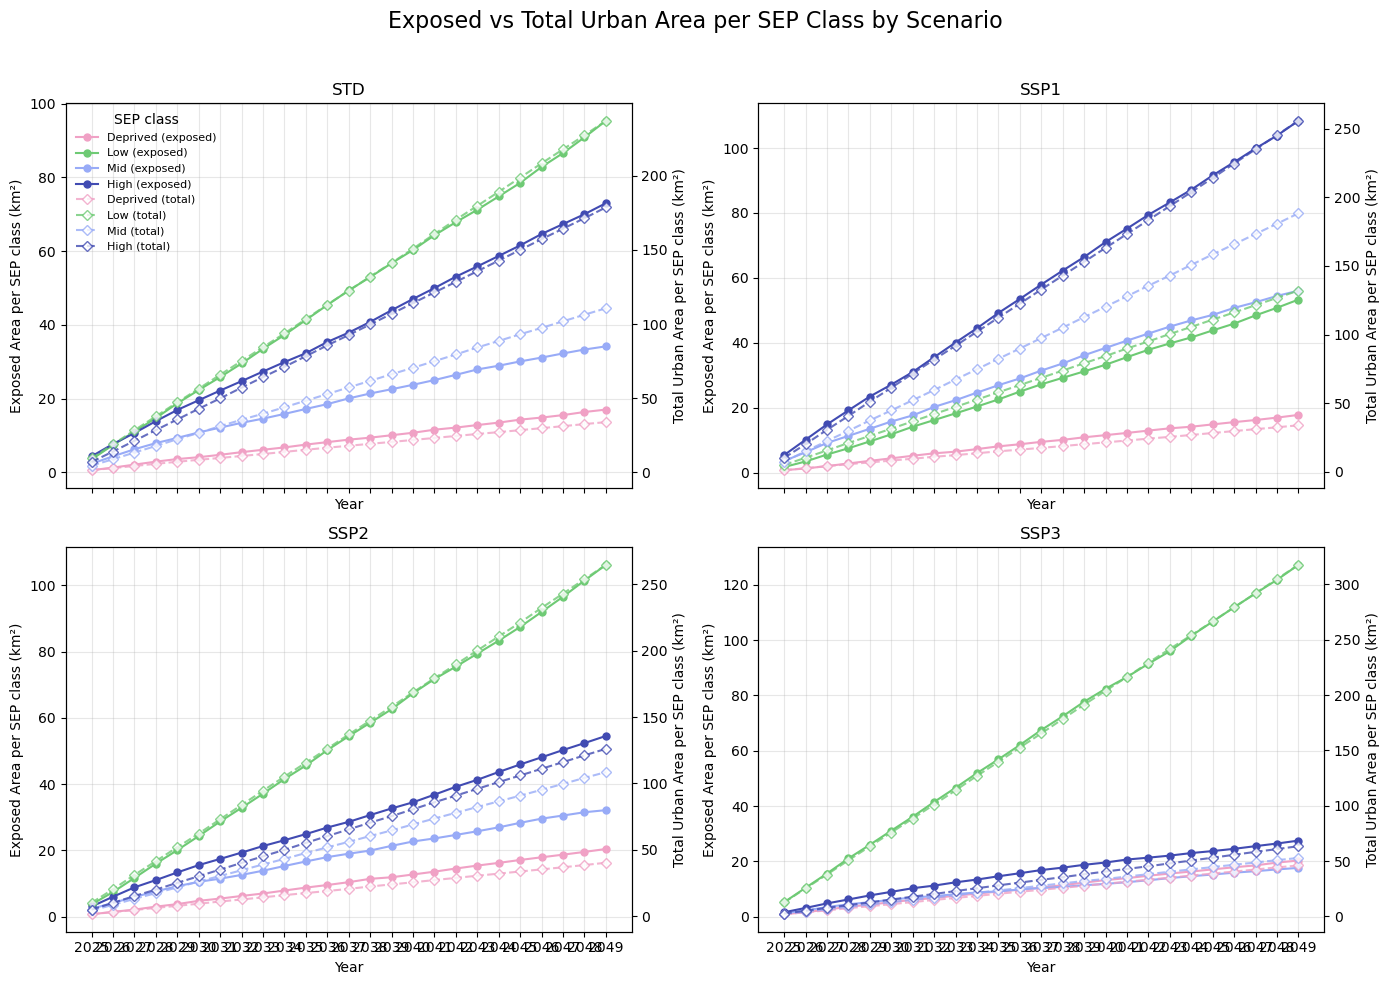

In [10]:
# using results_table as input, let's plot the results for each scenario. The years should be the x-axis. 
# The exposed area per SEP class will be the y-axis variable
# colours will come from agent_color_dict
# for the labels, we'll use the keys in agent_class_dict
# Create a secondary y-axis for total urban area (non-exposed)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()
marker_list = ['o','D']


for ax, scenario in zip(axes, scenario_list):
        df = results_table[results_table['Scenario'] == scenario].sort_values('Year')
        years = df['Year'].astype(int)
        exposed_mapping = {
                'deprived': 'Urban Area Exposed (deprived)',
                'low': 'Urban Area Exposed (low)',
                'mid': 'Urban Area Exposed (mid)',
                'high': 'Urban Area Exposed (high)'
        }
        
        # Primary axis: exposed areas
        for sep in ['deprived', 'low', 'mid', 'high']:
                col = exposed_mapping[sep]
                #print(col)
                ax.plot(years, df[col], marker=marker_list[0], linestyle='-', markersize=5,  label=f'{sep.capitalize()} (exposed)', color=agent_color_dict[sep])
                
        ax.set_title(scenario.upper())
        ax.set_xlabel('Year')
        ax.set_ylabel('Exposed Area per SEP class (km²)', color='black')
        ax.tick_params(axis='y', labelcolor='black')
        ax.grid(alpha=0.3)
        ax.set_xticks(years)
        ax.set_xticklabels(years.astype(str))
        
        # Secondary y-axis: total urban area (non-exposed)
        ax2 = ax.twinx()
        total_mapping = {
                'deprived': 'Urban Area (deprived)',
                'low': 'Urban Area (low)',
                'mid': 'Urban Area (mid)',
                'high': 'Urban Area (high)'
        }
        
        for sep in ['deprived', 'low', 'mid', 'high']:
                col = total_mapping[sep]
                #ax2.plot(years, df[col], marker=marker_list[1], linestyle='--', markersize=6, label=f'{sep.capitalize()} (total)', color=agent_color_dict[sep], alpha=0.8, markerfacecolor='none', markeredgecolor=agent_color_dict[sep], markeredgewidth=1.0)
                filled_marker_style = dict(marker=marker_list[1],  markersize=5,
                           color=agent_color_dict[sep],
                           markerfacecolor='white',
                           alpha=0.8,
                           #markerfacecoloralt='lightsteelblue',
                           linestyle='--',
                           markeredgecolor=agent_color_dict[sep])
                ax2.plot(years, df[col],  label=f'{sep.capitalize()} (total)', **filled_marker_style)
        
        ax2.set_ylabel('Total Urban Area per SEP class (km²)', color='black')
        ax2.tick_params(axis='y', labelcolor='black')
        
        if scenario == scenario_list[0]:
                lines1, labels1 = ax.get_legend_handles_labels()
                lines2, labels2 = ax2.get_legend_handles_labels()
                ax.legend(lines1 + lines2, labels1 + labels2, title='SEP class', 
                                 loc='upper left', frameon=False, fontsize=8)

for ax in axes[len(scenario_list):]:
        ax.set_visible(False)

fig.suptitle('Exposed vs Total Urban Area per SEP Class by Scenario', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [13]:
results_table.columns

Index(['Scenario', 'Year', 'Total Urban Area',
       'Urban Area Exposed to Flooding', 'Total New Urban Area',
       'New Urban Area Exposed to Flooding', 'Urban Area (deprived)',
       'Urban Area Exposed (deprived)', 'Urban Area (low)',
       'Urban Area Exposed (low)', 'Urban Area (mid)',
       'Urban Area Exposed (mid)', 'Urban Area (high)',
       'Urban Area Exposed (high)', 'Urban Area (urban_first_year)',
       'Urban Area Exposed (urban_first_year)'],
      dtype='object')

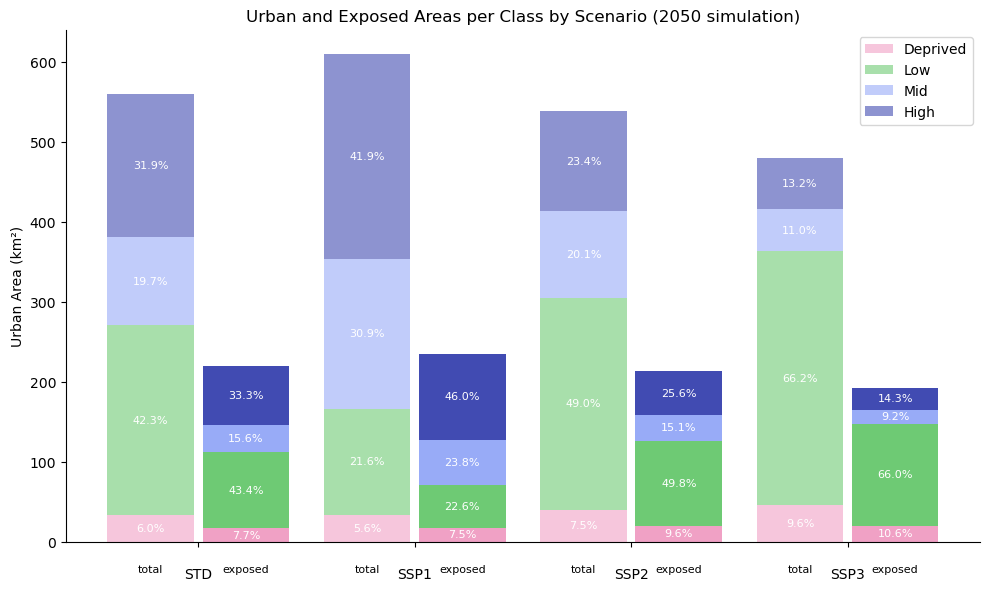

In [15]:
# Create the stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.4

# Get the last year for each scenario
results_table_last_year = results_table.sort_values("Year").groupby("Scenario").tail(1).reset_index(drop=True)

# Order scenarios: std, ssp1, ssp2, ssp3
scenario_order = ['std', 'ssp1', 'ssp2', 'ssp3']
results_table_last_year['Scenario'] = pd.Categorical(results_table_last_year['Scenario'], categories=scenario_order, ordered=True)
results_table_last_year = results_table_last_year.sort_values('Scenario').reset_index(drop=True)

# Extract data for the stacked bar chart
scenarios = results_table_last_year["Scenario"].tolist()
urban_area_deprived = results_table_last_year["Urban Area (deprived)"].values
urban_area_low = results_table_last_year["Urban Area (low)"].values
urban_area_mid = results_table_last_year["Urban Area (mid)"].values
urban_area_high = results_table_last_year["Urban Area (high)"].values

# Extract data for the exposed areas
urban_exposed_deprived = results_table_last_year["Urban Area Exposed (deprived)"].values
urban_exposed_low = results_table_last_year["Urban Area Exposed (low)"].values
urban_exposed_mid = results_table_last_year["Urban Area Exposed (mid)"].values
urban_exposed_high = results_table_last_year["Urban Area Exposed (high)"].values

# Normalize the data to percentages
urban_area_total = urban_area_deprived + urban_area_low + urban_area_mid + urban_area_high
urban_area_deprived_percentage = (urban_area_deprived / urban_area_total) * 100
urban_area_low_percentage = (urban_area_low / urban_area_total) * 100
urban_area_mid_percentage = (urban_area_mid / urban_area_total) * 100
urban_area_high_percentage = (urban_area_high / urban_area_total) * 100

# Normalize the exposed data to percentages
urban_exposed_total = urban_exposed_deprived + urban_exposed_low + urban_exposed_mid + urban_exposed_high
urban_exposed_deprived_percentage = (urban_exposed_deprived / urban_exposed_total) * 100
urban_exposed_low_percentage = (urban_exposed_low / urban_exposed_total) * 100
urban_exposed_mid_percentage = (urban_exposed_mid / urban_exposed_total) * 100
urban_exposed_high_percentage = (urban_exposed_high / urban_exposed_total) * 100


# Adjust the x positions for the second set of bars
x_positions = np.arange(len(scenarios))
x_positions_exposed = x_positions + bar_width * 1.1

# Plot each class as a stack
p1 = ax.bar(scenarios, urban_area_deprived, bar_width, label="Deprived")
p2 = ax.bar(scenarios, urban_area_low, bar_width, bottom=urban_area_deprived, label="Low")
p3 = ax.bar(scenarios, urban_area_mid, bar_width, bottom=urban_area_deprived + urban_area_low, label="Mid")
p4 = ax.bar(scenarios, urban_area_high, bar_width, bottom=urban_area_deprived + urban_area_low + urban_area_mid, label="High")

# Use the colors from agent_color_dict
colors = [agent_color_dict['deprived'], agent_color_dict['low'], agent_color_dict['mid'], agent_color_dict['high']]

# Apply colors to all bars in each stack with reduced alpha
alpha_decay = 0.6
for bar, color in zip(p1, [colors[0]] * len(p1)):
    bar.set_facecolor(color)
    bar.set_alpha(alpha_decay)
for bar, color in zip(p2, [colors[1]] * len(p2)):
    bar.set_facecolor(color)
    bar.set_alpha(alpha_decay)
for bar, color in zip(p3, [colors[2]] * len(p3)):
    bar.set_facecolor(color)
    bar.set_alpha(alpha_decay)
for bar, color in zip(p4, [colors[3]] * len(p4)):
    bar.set_facecolor(color)
    bar.set_alpha(alpha_decay)

# Plot the exposed areas as a second series of bars
p5 = ax.bar(x_positions_exposed, urban_exposed_deprived, bar_width) #, label="Exposed (Deprived)"
p6 = ax.bar(x_positions_exposed, urban_exposed_low, bar_width, bottom=urban_exposed_deprived)#, label="Exposed (Low)")
p7 = ax.bar(x_positions_exposed, urban_exposed_mid, bar_width, bottom=urban_exposed_deprived + urban_exposed_low) #, label="Exposed (Mid)")
p8 = ax.bar(x_positions_exposed, urban_exposed_high, bar_width, bottom=urban_exposed_deprived + urban_exposed_low + urban_exposed_mid)#, label="Exposed (High)")

# Apply colors to the exposed bars
for bar, color in zip(p5, [colors[0]] * len(p5)):
    bar.set_facecolor(color)
for bar, color in zip(p6, [colors[1]] * len(p6)):
    bar.set_facecolor(color)
for bar, color in zip(p7, [colors[2]] * len(p7)):
    bar.set_facecolor(color)
for bar, color in zip(p8, [colors[3]] * len(p8)):
    bar.set_facecolor(color)

# Add 'total' label under the total urban area bars
for xpos, label in zip(x_positions, scenarios):
    ax.text(xpos, -35, 'total', ha='center', va='center', fontsize=8, color='black')

# Add 'exposed' label under the exposed area bars
for xpos, label in zip(x_positions_exposed, scenarios):
    ax.text(xpos, -35, 'exposed', ha='center', va='center', fontsize=8, color='black')

# Add percentages for each class inside the corresponding area of the graph
for i, scenario in enumerate(scenarios):
    # Total urban area percentages
    ax.text(x_positions[i], urban_area_deprived[i] / 2, f"{urban_area_deprived_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions[i], urban_area_deprived[i] + urban_area_low[i] / 2, f"{urban_area_low_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions[i], urban_area_deprived[i] + urban_area_low[i] + urban_area_mid[i] / 2, f"{urban_area_mid_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions[i], urban_area_deprived[i] + urban_area_low[i] + urban_area_mid[i] + urban_area_high[i] / 2, f"{urban_area_high_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')

    # Exposed urban area percentages
    ax.text(x_positions_exposed[i], urban_exposed_deprived[i] / 2, f"{urban_exposed_deprived_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions_exposed[i], urban_exposed_deprived[i] + urban_exposed_low[i] / 2, f"{urban_exposed_low_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions_exposed[i], urban_exposed_deprived[i] + urban_exposed_low[i] + urban_exposed_mid[i] / 2, f"{urban_exposed_mid_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions_exposed[i], urban_exposed_deprived[i] + urban_exposed_low[i] + urban_exposed_mid[i] + urban_exposed_high[i] / 2, f"{urban_exposed_high_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')

# Adjust x-axis ticks and labels
ax.set_xticks(x_positions + bar_width * 1.1 / 2)
ax.set_xticklabels([label.upper() for label in scenarios], y=-0.03)
# Add labels, title, and legend
#ax.set_xlabel("Scenario", fontsize=12)
ax.set_ylabel("Urban Area (km²)")
ax.set_title("Urban and Exposed Areas per Class by Scenario (2050 simulation)")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()

In [34]:
# Save the figure as a PNG file with 300 dpi
file_name = case_city + '_urban_exposed_areas.png'
fig.savefig(file_name, dpi=300, format="png", bbox_inches="tight")


In [35]:
# Normalize the data to percentages for stacked bars
urban_area_deprived_percentage = (urban_area_deprived / urban_area_total) * 100
urban_area_low_percentage = (urban_area_low / urban_area_total) * 100
urban_area_mid_percentage = (urban_area_mid / urban_area_total) * 100
urban_area_high_percentage = (urban_area_high / urban_area_total) * 100

urban_exposed_deprived_percentage = (urban_exposed_deprived / urban_exposed_total) * 100
urban_exposed_low_percentage = (urban_exposed_low / urban_exposed_total) * 100
urban_exposed_mid_percentage = (urban_exposed_mid / urban_exposed_total) * 100
urban_exposed_high_percentage = (urban_exposed_high / urban_exposed_total) * 100

# Plot each class as a stack normalized to 100%
p1 = ax.bar(scenarios, urban_area_deprived_percentage, bar_width, label="Deprived")
p2 = ax.bar(scenarios, urban_area_low_percentage, bar_width, bottom=urban_area_deprived_percentage, label="Low")
p3 = ax.bar(scenarios, urban_area_mid_percentage, bar_width, bottom=urban_area_deprived_percentage + urban_area_low_percentage, label="Mid")
p4 = ax.bar(scenarios, urban_area_high_percentage, bar_width, bottom=urban_area_deprived_percentage + urban_area_low_percentage + urban_area_mid_percentage, label="High")

# Plot the exposed areas as a second series of bars normalized to 100%
p5 = ax.bar(x_positions_exposed, urban_exposed_deprived_percentage, bar_width)
p6 = ax.bar(x_positions_exposed, urban_exposed_low_percentage, bar_width, bottom=urban_exposed_deprived_percentage)
p7 = ax.bar(x_positions_exposed, urban_exposed_mid_percentage, bar_width, bottom=urban_exposed_deprived_percentage + urban_exposed_low_percentage)
p8 = ax.bar(x_positions_exposed, urban_exposed_high_percentage, bar_width, bottom=urban_exposed_deprived_percentage + urban_exposed_low_percentage + urban_exposed_mid_percentage)

# Adjust y-axis label to reflect percentages
ax.set_ylabel("Percentage (%)")
p2 = ax.bar(scenarios, urban_area_low, bar_width, bottom=urban_area_deprived, label="Low")
p3 = ax.bar(scenarios, urban_area_mid, bar_width, bottom=urban_area_deprived + urban_area_low, label="Mid")
p4 = ax.bar(scenarios, urban_area_high, bar_width, bottom=urban_area_deprived + urban_area_low + urban_area_mid, label="High")

# Use the colors from agent_color_dict
colors = [agent_color_dict['deprived'], agent_color_dict['low'], agent_color_dict['mid'], agent_color_dict['high']]

# Apply colors to all bars in each stack
for bar, color in zip(p1, [colors[0]] * len(p1)):
    bar.set_facecolor(color)
for bar, color in zip(p2, [colors[1]] * len(p2)):
    bar.set_facecolor(color)
for bar, color in zip(p3, [colors[2]] * len(p3)):
    bar.set_facecolor(color)
for bar, color in zip(p4, [colors[3]] * len(p4)):
    bar.set_facecolor(color)

# Plot the exposed areas as a second series of bars
p5 = ax.bar(x_positions_exposed, urban_exposed_deprived, bar_width) #, label="Exposed (Deprived)"
p6 = ax.bar(x_positions_exposed, urban_exposed_low, bar_width, bottom=urban_exposed_deprived)#, label="Exposed (Low)")
p7 = ax.bar(x_positions_exposed, urban_exposed_mid, bar_width, bottom=urban_exposed_deprived + urban_exposed_low) #, label="Exposed (Mid)")
p8 = ax.bar(x_positions_exposed, urban_exposed_high, bar_width, bottom=urban_exposed_deprived + urban_exposed_low + urban_exposed_mid)#, label="Exposed (High)")

# Apply colors to the exposed bars
for bar, color in zip(p5, [colors[0]] * len(p5)):
    bar.set_facecolor(color)
for bar, color in zip(p6, [colors[1]] * len(p6)):
    bar.set_facecolor(color)
for bar, color in zip(p7, [colors[2]] * len(p7)):
    bar.set_facecolor(color)
for bar, color in zip(p8, [colors[3]] * len(p8)):
    bar.set_facecolor(color)

# Add 'total' label under the total urban area bars
for xpos, label in zip(x_positions, scenarios):
    ax.text(xpos, -35, 'total', ha='center', va='center', fontsize=8, color='black')

# Add 'exposed' label under the exposed area bars
for xpos, label in zip(x_positions_exposed, scenarios):
    ax.text(xpos, -35, 'exposed', ha='center', va='center', fontsize=8, color='black')

# Add percentages for each class inside the corresponding area of the graph
for i, scenario in enumerate(scenarios):
    # Total urban area percentages
    ax.text(x_positions[i], urban_area_deprived_percentage[i] / 2, f"{urban_area_deprived_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions[i], urban_area_deprived_percentage[i] + urban_area_low_percentage[i] / 2, f"{urban_area_low_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions[i], urban_area_deprived_percentage[i] + urban_area_low_percentage[i] + urban_area_mid_percentage[i] / 2, f"{urban_area_mid_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions[i], urban_area_deprived_percentage[i] + urban_area_low_percentage[i] + urban_area_mid_percentage[i] + urban_area_high_percentage[i] / 2, f"{urban_area_high_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')

    # Exposed urban area percentages
    ax.text(x_positions_exposed[i], urban_exposed_deprived_percentage[i] / 2, f"{urban_exposed_deprived_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions_exposed[i], urban_exposed_deprived_percentage[i] + urban_exposed_low_percentage[i] / 2, f"{urban_exposed_low_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions_exposed[i], urban_exposed_deprived_percentage[i] + urban_exposed_low_percentage[i] + urban_exposed_mid_percentage[i] / 2, f"{urban_exposed_mid_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')
    ax.text(x_positions_exposed[i], urban_exposed_deprived_percentage[i] + urban_exposed_low_percentage[i] + urban_exposed_mid_percentage[i] + urban_exposed_high_percentage[i] / 2, f"{urban_exposed_high_percentage[i]:.1f}%", ha='center', va='center', fontsize=8, color='white')

# Adjust x-axis ticks and labels
ax.set_xticks(x_positions + bar_width * 1.1 / 2)
ax.set_xticklabels([label.upper() for label in scenarios], y=-0.03)
# Add labels, title, and legend
#ax.set_xlabel("Scenario", fontsize=12)
ax.set_ylabel("Urban Area (km²)")
ax.set_title("Urban and Exposed Areas per Class by Scenario (2050 simulation)")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

## 3.2 Compare model results with the calibration data

In [54]:
admin3_file = interim_path / (case_city + '_POP_HDI_component_estimates_ADMlvl3_A.gpkg')
admin3_gdf = gpd.read_file(admin3_file)

In [55]:
# calculate the exposed area for each admin 3 unit
admin3_gdf['exp_surface'] = rasterstats.zonal_stats(admin3_gdf, exposure_raster, affine=exposure_raster_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
admin3_gdf['exp_surface'] = admin3_gdf['exp_surface'].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan)

In [63]:
# calculate population for each socioeconomic profile per admin 3 unit
modelled_pop_list = ['pop_deprived_model', 'pop_low_model', 'pop_mid_model', 'pop_high_model']
model_scenario_list = ['std', 'ssp1', 'ssp2','ssp3']
if case_city == 'JAK':
    cell_conversion_factor = 310.34 #determined by the average number of households per pixel
else:
    cell_conversion_factor = 1 # need to determine this for other cases

#admin3_gdf['exp_surface'] = rasterstats.zonal_stats(admin3_gdf, exposure_raster, affine=array_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
for scenario in model_scenario_list:
    var_deprived = 'pop_deprived_model_' + scenario
    var_low = 'pop_low_model_' + scenario
    var_mid = 'pop_mid_model_' + scenario
    var_high = 'pop_high_model_' + scenario
    deprived_array = np.where(results_dict[scenario] == 4, 1, 0)
    admin3_gdf[var_deprived] = rasterstats.zonal_stats(admin3_gdf, deprived_array, affine=array_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
    admin3_gdf[var_deprived] = admin3_gdf[var_deprived].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan) * cell_conversion_factor
    low_array = np.where(results_dict[scenario] == 1, 1, 0)
    admin3_gdf[var_low] = rasterstats.zonal_stats(admin3_gdf, low_array, affine=array_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
    admin3_gdf[var_low] = admin3_gdf[var_low].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan) * cell_conversion_factor
    mid_array = np.where(results_dict[scenario] == 2, 1, 0)
    admin3_gdf[var_mid] = rasterstats.zonal_stats(admin3_gdf, mid_array, affine=array_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
    admin3_gdf[var_mid] = admin3_gdf[var_mid].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan) * cell_conversion_factor
    high_array = np.where(results_dict[scenario] == 3, 1, 0)
    admin3_gdf[var_high] = rasterstats.zonal_stats(admin3_gdf, high_array, affine=array_meta['transform'], stats=['sum'], nodata=0, geojson_out=False, raster_out=False)
    admin3_gdf[var_high] = admin3_gdf[var_high].apply(lambda x: x['sum'] if isinstance(x, dict) else np.nan) * cell_conversion_factor

In [64]:
admin3_gdf.loc[:,['pop_deprived_model_std','pop_mid_model_std','pop_deprived_model_ssp1','pop_mid_model_ssp1']].head()

,pop_deprived_model_std,pop_mid_model_std,pop_deprived_model_ssp1,pop_mid_model_ssp1
0,16448.02,10551.56,15517.0,47171.68
1,NaN,310.34,NaN,310.34
2,22965.16,19241.08,13965.3,49964.74
3,NaN,931.02,NaN,1862.04
4,NaN,931.02,NaN,1862.04


In [65]:
# add the 2025 population
for scenario in model_scenario_list:
    var_deprived = 'pop_deprived_model_' + scenario 
    var_low = 'pop_low_model_' + scenario 
    var_mid = 'pop_mid_model_' + scenario 
    var_high = 'pop_high_model_' + scenario
    admin3_gdf[var_deprived] = np.round(admin3_gdf[var_deprived] + admin3_gdf['pop_deprived_2025'], 2)
    admin3_gdf[var_low] = np.round(admin3_gdf[var_low] + admin3_gdf['pop_low_2025'], 2)
    admin3_gdf[var_mid] = np.round(admin3_gdf[var_mid] + admin3_gdf['pop_medium_2015'] ,2)
    admin3_gdf[var_high] = np.round(admin3_gdf[var_high] + admin3_gdf['pop_high_2025'] ,2)

admin3_gdf.loc[:,['pop_deprived_model_std','pop_mid_model_std','pop_deprived_model_ssp1','pop_mid_model_ssp1']].head()


,pop_deprived_model_std,pop_mid_model_std,pop_deprived_model_ssp1,pop_mid_model_ssp1
0,42049.47,10551.56,41118.45,47171.68
1,NaN,61755.09,NaN,61755.09
2,80454.88,19241.08,71455.02,49964.74
3,NaN,26038.88,NaN,26969.90
4,NaN,25478.96,NaN,26409.98


In [68]:
# calculate the proportional exposed population for each admin 3 unit and scenario
for scenario in model_scenario_list:
    var_deprived = 'pop_deprived_model_exp_' + scenario 
    var_low = 'pop_low_model_exp_' + scenario 
    var_mid = 'pop_mid_model_exp_' + scenario 
    var_high = 'pop_high_model_exp_' + scenario

    ref_var_deprived = 'pop_deprived_model_' + scenario 
    ref_var_low = 'pop_low_model_' + scenario 
    ref_var_mid = 'pop_mid_model_' + scenario 
    ref_var_high = 'pop_high_model_' + scenario
    ref_var_total = 'pop_total_model_' + scenario

    admin3_gdf[ref_var_total] = admin3_gdf[ref_var_deprived] + admin3_gdf[ref_var_low] + admin3_gdf[ref_var_mid] + admin3_gdf[ref_var_high] 
    admin3_gdf[var_deprived] = (admin3_gdf[ref_var_deprived]/admin3_gdf[ref_var_total] )* admin3_gdf['exp_surface']
    admin3_gdf[var_low] = (admin3_gdf[ref_var_low]/admin3_gdf[ref_var_total] )* admin3_gdf['exp_surface']
    admin3_gdf[var_mid] = (admin3_gdf[ref_var_mid]/admin3_gdf[ref_var_total] )* admin3_gdf['exp_surface']
    admin3_gdf[var_high] = (admin3_gdf[ref_var_high]/admin3_gdf[ref_var_total] )* admin3_gdf['exp_surface']

# calculate the proportional exposed population for 2015 and 2025

var_deprived_early = f'pop_deprived_exp_{calibration_years[0]}'
var_low_early = f'pop_low_exp_{calibration_years[0]}'
var_mid_early = f'pop_mid_exp_{calibration_years[0]}'
var_high_early = f'pop_high_model_exp_{calibration_years[0]}'

var_deprived_late = f'pop_deprived_exp_{calibration_years[1]}'
var_low_late = f'pop_low_exp_{calibration_years[1]}'
var_mid_late = f'pop_mid_exp_{calibration_years[1]}'
var_high_late = f'pop_high_exp_{calibration_years[1]}'

ref_var_deprived_early = f'pop_deprived_{calibration_years[0]}'
ref_var_low_early = f'pop_low_{calibration_years[0]}'
ref_var_mid_early = f'pop_medium_{calibration_years[0]}'
ref_var_high_early = f'pop_high_{calibration_years[0]}'
ref_var_total_early = f'pop_total_{calibration_years[0]}'

ref_var_deprived_late = f'pop_deprived_{calibration_years[1]}'
ref_var_low_late = f'pop_low_{calibration_years[1]}'
ref_var_mid_late = f'pop_medium_{calibration_years[1]}'
ref_var_high_late = f'pop_high_{calibration_years[1]}'
ref_var_total_late = f'pop_total_{calibration_years[1]}'

admin3_gdf[ref_var_total_early] = admin3_gdf[ref_var_deprived_early] + admin3_gdf[ref_var_low_early] + admin3_gdf[ref_var_mid_early] + admin3_gdf[ref_var_high_early] 

admin3_gdf[var_deprived_early] = (admin3_gdf[ref_var_deprived_early]/admin3_gdf[ref_var_total_early] )* admin3_gdf['exp_surface']
admin3_gdf[var_low_early] = (admin3_gdf[ref_var_low_early]/admin3_gdf[ref_var_total_early] )* admin3_gdf['exp_surface']
admin3_gdf[var_mid_early] = (admin3_gdf[ref_var_mid_early]/admin3_gdf[ref_var_total_early] )* admin3_gdf['exp_surface']
admin3_gdf[var_high_early] = (admin3_gdf[ref_var_high_early]/admin3_gdf[ref_var_total_early] )* admin3_gdf['exp_surface']

admin3_gdf[ref_var_total_late] = admin3_gdf[ref_var_deprived_late] + admin3_gdf[ref_var_low_late] + admin3_gdf[ref_var_mid_late] + admin3_gdf[ref_var_high_late] 

admin3_gdf[var_deprived_late] = (admin3_gdf[ref_var_deprived_late]/admin3_gdf[ref_var_total_late] )* admin3_gdf['exp_surface']
admin3_gdf[var_low_late] = (admin3_gdf[ref_var_low_late]/admin3_gdf[ref_var_total_late] )* admin3_gdf['exp_surface']
admin3_gdf[var_mid_late] = (admin3_gdf[ref_var_mid_late]/admin3_gdf[ref_var_total_late] )* admin3_gdf['exp_surface']
admin3_gdf[var_high_late] = (admin3_gdf[ref_var_high_late]/admin3_gdf[ref_var_total_late] )* admin3_gdf['exp_surface']

In [69]:
# export a shapefile with the statistics
file_name = interim_path / (case_city + f'_POP_model_exposure_estimates_ADMlvl3_A.gpkg')
#admin3_file = interim_path / (case_city + '_POP_HDI_component_estimates_ADMlvl3_A.gpkg')
admin3_gdf.to_file(file_name, driver='GPKG')

In [70]:
# Create a summary table of exposed population for each scenario, including early and late calibration years
exposed_pop_summary = {}

scenarios_to_include = ['2015', '2025'] + model_scenario_list

for scenario in scenarios_to_include:
    if scenario == '2015':
        var_deprived = var_deprived_early
        var_low = var_low_early
        var_mid = var_mid_early
        var_high = var_high_early
    elif scenario == '2025':
        var_deprived = var_deprived_late
        var_low = var_low_late
        var_mid = var_mid_late
        var_high = var_high_late
    else:
        var_deprived = 'pop_deprived_model_exp_' + scenario 
        var_low = 'pop_low_model_exp_' + scenario 
        var_mid = 'pop_mid_model_exp_' + scenario 
        var_high = 'pop_high_model_exp_' + scenario
    
    exposed_pop_summary[scenario] = {
        'Exposed Pop (Deprived)': np.round(admin3_gdf[var_deprived].sum(),2),
        'Exposed Pop (Low)': np.round(admin3_gdf[var_low].sum(), 2),
        'Exposed Pop (Mid)': np.round(admin3_gdf[var_mid].sum(), 2),
        'Exposed Pop (High)': np.round(admin3_gdf[var_high].sum(), 2)
    }

# Convert to DataFrame
exposed_pop_table = pd.DataFrame.from_dict(exposed_pop_summary, orient='index')
exposed_pop_table


,Exposed Pop (Deprived),Exposed Pop (Low),Exposed Pop (Mid),Exposed Pop (High)
2015,58770.97,34744.32,15768.87,6876.84
2025,61855.62,32418.99,15216.07,6670.32
std,8577.57,19241.69,6973.07,6306.66
ssp1,6928.35,12688.25,8930.23,8745.16
ssp2,10282.48,20310.07,7033.75,6366.70
ssp3,7505.59,18918.75,5120.30,3190.36


In [42]:
# calculate the exposure for each socioeconomic profile based on the proportion of exposed area and of that population group in each admin 3 unit
exp_deprived_early = 
exp_low_early
exp_mid_early
exp_high_early

exp_deprived_late = 
exp_low_late
exp_mid_late
exp_high_late

exp_deprived_model = 
exp_low_model
exp_mid_model
exp_high_model

SyntaxError: invalid syntax (3929900972.py, line 2)

# The end (for now).

## NetLogo scripts (for reference/development)
just holding them here for now

In [ ]:
(count households with [(income-status = 1) and (LIH-movement = 0)] ) # LI HH left
(count households with [(income-status = 2) and (MIH-movement = 0)] ) # MI HH left
(count households with [(income-status = 3) and (HIH-movement = 0)] ) # HI HH left
(count households with [(income-status = 4) and (DPH-movement = 0)] ) # deprived HH left

In [ ]:
plot ((count patches with [DP-movement = 1 and new-urban = 1]) / (1 + count patches with [ new-urban = 1])) * 100
plot ((count patches with [DP-movement = 1 and informality = 1]) / (1 + count patches with [DP-movement = 1])) * 100
plot ((count patches with [DP-movement = 1 and informal_avail = 1]) / (1 + count patches with [ new-urban = 1 and informal_avail = 1])) * 100

In [ ]:
plot ((count patches with [LI-movement = 1 and new-urban = 1]) / (1 + count patches with [ new-urban = 1])) * 100
plot (((count patches with [MI-movement = 1 and new-urban = 1]) + (count patches with [pMED-movement = 1 and new-urban = 1])) / (1 + count patches with [ new-urban = 1 ])) * 100
plot (((count patches with [HI-movement = 1 and new-urban = 1]) + (count patches with [pHED-movement = 1 and new-urban = 1])) / (1 + count patches with [ new-urban = 1 ])) * 100

In [ ]:
plot (((count patches with [HI-movement = 1 and informality = 1]) + (count patches with [pHED-movement = 1 and informality = 1])) / ((1 + count patches with [HI-movement = 1]) + (count patches with [pHED-movement = 1]))) * 100
plot (((count patches with [MI-movement = 1 and informality = 1]) + (count patches with [pMED-movement = 1 and informality = 1])) / ((1 + count patches with [MI-movement = 1]) + (count patches with [pMED-movement = 1]))) * 100

In [ ]:
(ifelse 
    scenario = "standard" 
    [ 
      ] ;; standard true
    [ ifelse scenario = "SSP1" ;; else
      [ 
        ] ;; SSP1 true (standard false)
      [ ifelse scenario = "SSP2" ;; else
        [ 
          ] ;; SSP2 true 
        [ if scenario = "SSP3" ;; else
          [  
            ] ;; SSP3 true 
        ] ;; SSP3 false
      ] ;; SSP2 false
    ] ;; SSP1 false
  )

In [ ]:
(ifelse 
    scenario = "standard" 
    [ set 
     [ household-number percent-deprived-households percent-low-income-households percent-mid-income-households percent-high-income-households slope_coefficient critical_slope development_control] 
     [ 23959 10 30 50 10 80 17 50 ]
      ] ;; standard true
    [ ifelse scenario = "SSP1" ;; standard else
      [ set 
       [ household-number percent-deprived-households percent-low-income-households percent-mid-income-households percent-high-income-households slope_coefficient critical_slope development_control] 
       [ 31677 7 21 55 17 80 17 80 ] 
        ] ;; SSP1 true (standard false)
      [ ifelse scenario = "SSP2" ;; SSP1 else
       [ set
        [ household-number percent-deprived-households percent-low-income-households percent-mid-income-households percent-high-income-households slope_coefficient critical_slope development_control] 
        [ 51168 10 30 50 10 80 25 50 ] 
        ]  ;; SSP2 true 
        [ if scenario = "SSP3" ;; SSP2 else
         [ set 
          [ household-number percent-deprived-households percent-low-income-households percent-mid-income-households percent-high-income-households slope_coefficient critical_slope development_control] 
          [ 71629 17 48 28 7 80 35 30 ] 
        ] ;; SSP3 true 
        ] ;; closing SSP3
      ] ;; closing SSP2 
    ] ;; closing SSP1 
)

In [ ]:
Allocation error
Requested 3,438 random agents from a set of only 3,183 agents.
error while observer running MAX-N-OF
  called by procedure MAKE-LOW-INCOME-HOUSEHOLD-DEVELOPMENT
  called by procedure GO
  called by Button 'Go'